NAME:SAMIM ALI
ROLL NO :24MDS031

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

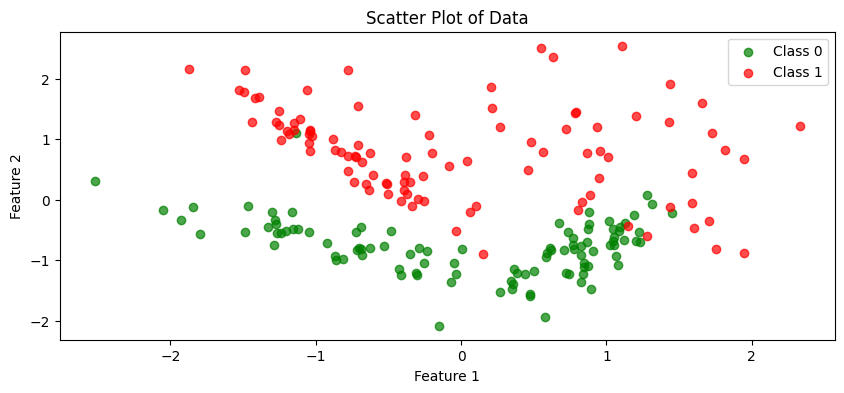

In [14]:
plt.figure(figsize=(10, 4))
for label, color in zip([0, 1], ['green', 'red']):
    plt.scatter(X[y == label, 0], X[y == label, 1], color=color, label=f'Class {label}', alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter Plot of Data')
plt.legend()
plt.show()

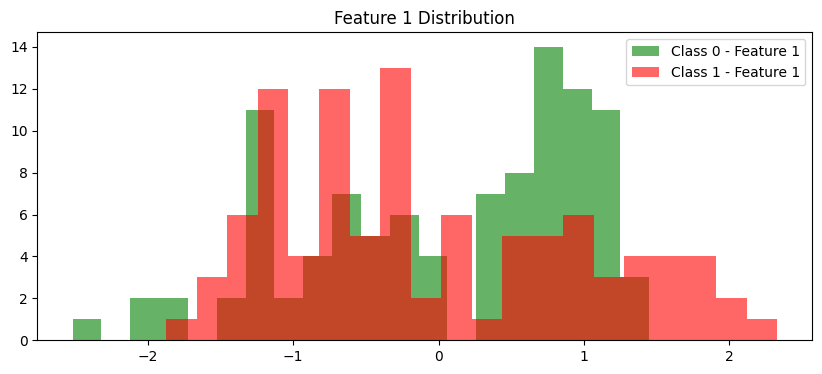

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(X[y==0, 0], bins=20, alpha=0.6, label='Class 0 - Feature 1', color='green')
plt.hist(X[y==1, 0], bins=20, alpha=0.6, label='Class 1 - Feature 1', color='red')
plt.legend()
plt.title("Feature 1 Distribution")
plt.show()

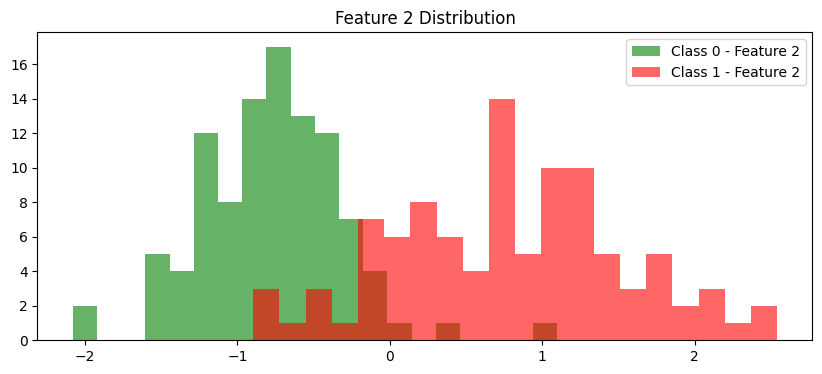

In [17]:
plt.figure(figsize=(10, 4))
plt.hist(X[y==0, 1], bins=20, alpha=0.6, label='Class 0 - Feature 2', color='green')
plt.hist(X[y==1, 1], bins=20, alpha=0.6, label='Class 1 - Feature 2', color='red')
plt.legend()
plt.title("Feature 2 Distribution")
plt.show()

In [18]:
prior_0 = np.mean(y_train == 0)
prior_1 = np.mean(y_train == 1)

class0 = X_train[y_train == 0]
class1 = X_train[y_train == 1]
classes = [class0, class1]
means = [np.mean(i, axis=0) for i in classes]
stds  = [np.std (i, axis=0) for i in classes]


In [19]:
def likelihood(x, mean, std):
    return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((x - mean) ** 2) / (2 * std ** 2))

In [20]:
def predict(sample):
    likelihood_0 = np.prod([likelihood(sample[i], means[0][i], stds[0][i]) for i in range(len(sample))])
    likelihood_1 = np.prod([likelihood(sample[i], means[1][i], stds[1][i]) for i in range(len(sample))])
    posterior_0 = prior_0 * likelihood_0
    posterior_1 = prior_1 * likelihood_1
    evidence = posterior_0 + posterior_1
    posterior_0 /= evidence
    posterior_1 /= evidence
    return (posterior_0, posterior_1, 0 if posterior_0 > posterior_1 else 1)

In [21]:
test_sample = X_test[0]
test_sample, y_test[0]

(array([-0.62444331,  0.7699421 ]), np.int64(1))

In [22]:
predict(test_sample)

(np.float64(0.0005048175059034893), np.float64(0.9994951824940965), 1)

In [23]:
model = GaussianNB()
model.fit(X_train, y_train)
model.predict_proba([test_sample])[0], model.predict([test_sample])[0]

(array([5.04817533e-04, 9.99495182e-01]), np.int64(1))